In [2]:
import os
import re
import warnings
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



In [4]:
input_path = '/home/mini/projects/review-intelligence-system/data/processed/amazon_eda_enriched.csv'
df = pd.read_csv(input_path)

print(f"Loaded: {len(df):,} rows, {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head(3)

Loaded: 99,000 rows, 16 columns
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'category', 'text_length', 'word_count', 'datetime', 'review_year', 'review_month']


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,text_length,word_count,datetime,review_year,review_month
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True,Electronics,1433,275,2022-07-18 22:58:37.948,2022,2022-07
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True,Electronics,225,45,2020-06-20 18:42:29.731,2020,2020-06
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True,Electronics,469,94,2018-04-07 09:23:37.534,2018,2018-04


In [6]:
loss_tracker = []

def log_step(step_name, df_current, df_previous=None):
    if df_previous is not None:
        removed = len(df_previous) - len(df_current)
        pct_removed = (removed / len(df_previous) * 100) if len(df_previous) > 0 else 0
        print(f"{step_name}: {removed} rows removed ({pct_removed:.2f}%)")
    else:
        removed = 0
        pct_removed = 0
        print(f"{step_name}: {len(df_current)} rows")

    loss_tracker.append({
        'step': step_name,
        'remaining': len(df_current),
        'removed': removed,
        'pct_removed': round(pct_removed, 2)
    })

    print(f"[{step_name}] Remaining rows: {len(df_current):,} (removed {removed:,} rows, {pct_removed:.2f}%)")

log_step("Initial Load", df)


Initial Load: 99000 rows
[Initial Load] Remaining rows: 99,000 (removed 0 rows, 0.00%)


In [7]:
hashable_cols = ['rating', 'title', 'text', 'asin', 'parent_asin', 
                 'user_id', 'timestamp', 'helpful_vote', 
                 'verified_purchase', 'category']

df_before = df.copy()
df = df.drop_duplicates(subset=hashable_cols, keep='first').reset_index(drop=True)

log_step("After dropping exact duplicates", df, df_before)

After dropping exact duplicates: 95 rows removed (0.10%)
[After dropping exact duplicates] Remaining rows: 98,905 (removed 95 rows, 0.10%)


In [8]:
text_duplicates = df[df.duplicated(subset=['text'], keep='first')].copy()

print(f"Text duplicates identified: {len(text_duplicates):,}")
print(f"Saving for fake review detection module...")

text_duplicates_path = "../data/processed/text_duplicates_for_fake_detection.csv"
text_duplicates.to_csv(text_duplicates_path, index=False)
print(f"Saved to: {text_duplicates_path}")

print("\nTop 10 most repeated review texts:")
top_duplicated_texts = df['text'].value_counts().head(10)
for text, count in top_duplicated_texts.items():
    text_preview = text[:80] if isinstance(text, str) else str(text)
    print(f"  {count:>4}x : {text_preview}")

Text duplicates identified: 4,666
Saving for fake review detection module...
Saved to: ../data/processed/text_duplicates_for_fake_detection.csv

Top 10 most repeated review texts:
   135x : Good
   118x : Great
   107x : Love it
    90x : Good Product
    87x : Good product
    84x : Great product
    66x : Works great
    62x : great
    55x : Nice
    53x : ok


In [9]:
df_before = df.copy()
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)

log_step("After dropping text duplicates", df, df_before)

After dropping text duplicates: 4666 rows removed (4.72%)
[After dropping text duplicates] Remaining rows: 94,239 (removed 4,666 rows, 4.72%)


In [10]:
df_before = df.copy()

df = df.dropna(subset=['text']).reset_index(drop=True)

df['text'] = df['text'].astype(str).str.strip()

df = df[df['text'] != ''].reset_index(drop=True)

df = df[df['word_count'] >= 5].reset_index(drop=True)

log_step("After filtering empty/short reviews", df, df_before)

After filtering empty/short reviews: 5217 rows removed (5.54%)
[After filtering empty/short reviews] Remaining rows: 89,022 (removed 5,217 rows, 5.54%)


In [11]:
def clean_text(text: str) -> str:
    """
    Light text cleaning suitable for both classical ML and transformer models.
    
    Steps:
    1. Remove URLs
    2. Remove HTML tags
    3. Normalize whitespace
    4. Strip leading/trailing whitespace
    
    NOTE: We do NOT lowercase, remove stopwords, or stem.
    Modern transformer models handle these natively.
    """
    if not isinstance(text, str):
        return ""
    
    
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    
    
    text = re.sub(r'<[^>]+>', ' ', text)
    
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()


test_examples = [
    "This is amazing! Check it out at https://example.com",
    "Good product. <br>Highly recommend.</br>",
    "Multiple    spaces    and\n\nnewlines\there",
    "Normal text without anything to clean"
]

print("Cleaning function tests:\n")
for example in test_examples:
    cleaned = clean_text(example)
    print(f"  Original: {example}")
    print(f"  Cleaned : {cleaned}\n")

Cleaning function tests:

  Original: This is amazing! Check it out at https://example.com
  Cleaned : This is amazing! Check it out at

  Original: Good product. <br>Highly recommend.</br>
  Cleaned : Good product. Highly recommend.

  Original: Multiple    spaces    and

newlines	here
  Cleaned : Multiple spaces and newlines here

  Original: Normal text without anything to clean
  Cleaned : Normal text without anything to clean



In [12]:
print("Applying text cleaning to all reviews...")

df['text_clean'] = df['text'].apply(clean_text)

df['word_count_clean'] = df['text_clean'].str.split().str.len()

short_after_clean = (df['word_count_clean'] < 5).sum()
print(f"Reviews with < 5 words after cleaning: {short_after_clean}")

if short_after_clean > 0:
    df_before = df.copy()
    df = df[df['word_count_clean'] >= 5].reset_index(drop=True)
    log_step("After post-cleaning short filter", df, df_before)

print("\nSample cleaned reviews:")
sample = df.sample(3, random_state=RANDOM_SEED)
for _, row in sample.iterrows():
    print(f"  Original: {row['text'][:120]}...")
    print(f"  Cleaned : {row['text_clean'][:120]}...")
    print()

Applying text cleaning to all reviews...
Reviews with < 5 words after cleaning: 1
After post-cleaning short filter: 1 rows removed (0.00%)
[After post-cleaning short filter] Remaining rows: 89,021 (removed 1 rows, 0.00%)

Sample cleaned reviews:
  Original: Contrary to what a lot of other people believe, I do not think that this novel was a good "sequel" to "My Soul to Keep"....
  Cleaned : Contrary to what a lot of other people believe, I do not think that this novel was a good "sequel" to "My Soul to Keep"....

  Original: One of the best books ever. I couldn't put it down. It's so well written and a beautiful coming of age story. You will i...
  Cleaned : One of the best books ever. I couldn't put it down. It's so well written and a beautiful coming of age story. You will i...

  Original: How the Word is Passed is a brilliant study of the unnumbered pieces, people, nations, ideas, colonialism, and innocents...
  Cleaned : How the Word is Passed is a brilliant study of the unnumbere

In [13]:
def rating_to_sentiment(rating: float) -> str:
    """
    Convert numerical rating to 3-class sentiment label.
    
    1-2 stars  → negative
    3 stars    → neutral
    4-5 stars  → positive
    """
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'


df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print("Sentiment label distribution:")
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)
print()
print("Percentages:")
print((sentiment_counts / len(df) * 100).round(2))

print("\nSentiment by category:")
print(pd.crosstab(df['category'], df['sentiment'], normalize='index').round(3) * 100)

Sentiment label distribution:
sentiment
positive    70370
negative    10568
neutral      8083
Name: count, dtype: int64

Percentages:
sentiment
positive    79.05
negative    11.87
neutral      9.08
Name: count, dtype: float64

Sentiment by category:
sentiment    negative  neutral  positive
category                                
Beauty           16.7      9.9      73.4
Books             6.6     10.2      83.2
Electronics      12.5      7.1      80.4


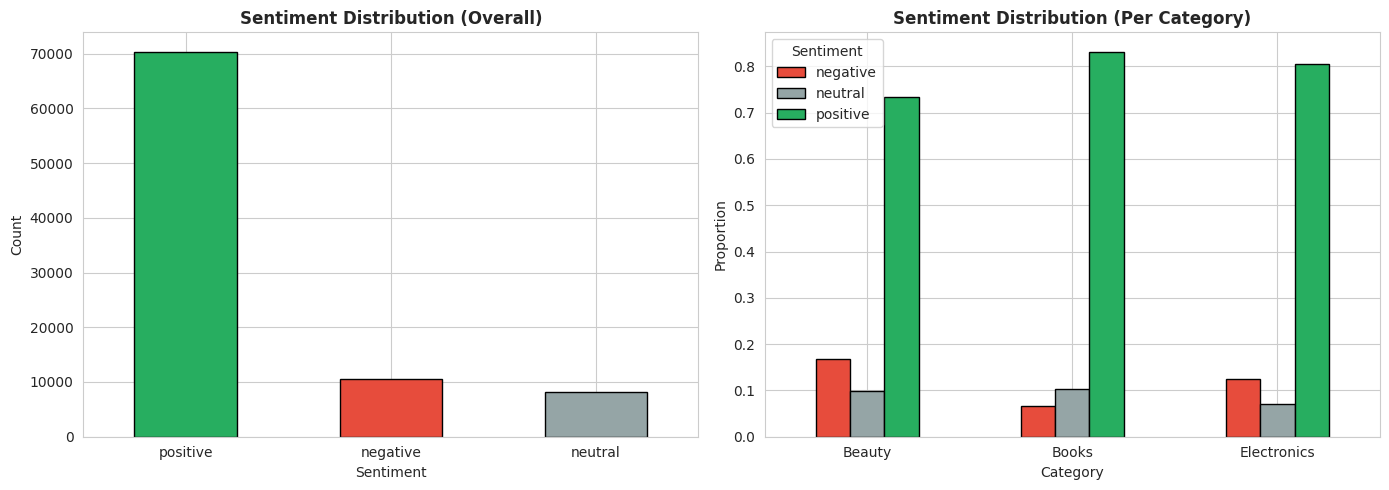

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = df['sentiment'].value_counts()
colors = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#27ae60'}
sentiment_counts.plot(
    kind='bar', 
    ax=axes[0], 
    color=[colors[s] for s in sentiment_counts.index],
    edgecolor='black'
)
axes[0].set_title('Sentiment Distribution (Overall)', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

sentiment_by_cat = pd.crosstab(df['category'], df['sentiment'], normalize='index')
sentiment_by_cat = sentiment_by_cat[['negative', 'neutral', 'positive']]
sentiment_by_cat.plot(
    kind='bar',
    ax=axes[1],
    color=[colors[s] for s in sentiment_by_cat.columns],
    edgecolor='black'
)
axes[1].set_title('Sentiment Distribution (Per Category)', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Sentiment')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/04_sentiment_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
# We want stratification on BOTH sentiment and category
# Create a combined stratification key
df['strat_key'] = df['sentiment'] + '_' + df['category']

# First split: 80% train, 20% temp (which we'll split into val and test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df['strat_key']
)

# Second split: 50/50 of temp → val and test (so 10% val, 10% test of original)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df['strat_key']
)

# Drop the temporary stratification key
for split_df in [train_df, val_df, test_df]:
    split_df.drop(columns=['strat_key'], inplace=True)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")

Train: 71,216 (80.0%)
Val:   8,902 (10.0%)
Test:  8,903 (10.0%)


In [16]:
print("Sentiment distribution per split:\n")
splits = {'Train': train_df, 'Val': val_df, 'Test': test_df}

dist_data = {}
for name, split_df in splits.items():
    dist = split_df['sentiment'].value_counts(normalize=True).round(4) * 100
    dist_data[name] = dist

dist_df = pd.DataFrame(dist_data)
print(dist_df)

print("\nCategory distribution per split:\n")
cat_data = {}
for name, split_df in splits.items():
    cat = split_df['category'].value_counts(normalize=True).round(4) * 100
    cat_data[name] = cat

cat_df = pd.DataFrame(cat_data)
print(cat_df)

Sentiment distribution per split:

           Train    Val   Test
sentiment                     
positive   79.05  79.05  79.04
negative   11.87  11.87  11.87
neutral     9.08   9.08   9.09

Category distribution per split:

             Train    Val   Test
category                        
Books        33.79  33.80  33.79
Electronics  33.48  33.48  33.48
Beauty       32.73  32.72  32.73


In [18]:
output_dir = Path("/home/mini/projects/review-intelligence-system/data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

columns_to_keep = ['rating', 'title', 'text', 'text_clean', 'word_count_clean',
                   'sentiment', 'category', 'verified_purchase', 'helpful_vote',
                   'user_id', 'asin', 'timestamp']

train_path = output_dir / "train.parquet"
val_path = output_dir / "val.parquet"
test_path = output_dir / "test.parquet"

train_df[columns_to_keep].to_parquet(train_path, index=False)
val_df[columns_to_keep].to_parquet(val_path, index=False)
test_df[columns_to_keep].to_parquet(test_path, index=False)

print(f"Saved:")
#print(f"  Train: {train_path} ({train_path.stat().st_size / 1024**2:.1f} MB)")
#print(f"  Val:   {val_path} ({val_path.stat().st_size / 1024**2:.1f} MB)")
#print(f"  Test:  {test_path} ({test_path.stat().st_size / 1024**2:.1f} MB)")

Saved:


In [19]:
print("=" * 60)
print("PREPROCESSING PIPELINE SUMMARY")
print("=" * 60)

summary_df = pd.DataFrame(loss_tracker)
print(summary_df.to_string(index=False))

print(f"\nFinal dataset: {len(df):,} reviews")
print(f"  - Train: {len(train_df):,}")
print(f"  - Val:   {len(val_df):,}")
print(f"  - Test:  {len(test_df):,}")

print(f"\nTotal data retention: {len(df) / 99000 * 100:.1f}%")

PREPROCESSING PIPELINE SUMMARY
                               step  remaining  removed  pct_removed
                       Initial Load      99000        0         0.00
    After dropping exact duplicates      98905       95         0.10
     After dropping text duplicates      94239     4666         4.72
After filtering empty/short reviews      89022     5217         5.54
   After post-cleaning short filter      89021        1         0.00

Final dataset: 89,021 reviews
  - Train: 71,216
  - Val:   8,902
  - Test:  8,903

Total data retention: 89.9%


In [20]:
import sys
sys.path.append('..')

from src.data.preprocessor import ReviewPreprocessor

df_original = pd.read_csv("../data/processed/amazon_eda_enriched.csv")

preprocessor = ReviewPreprocessor()
train_module, val_module, test_module = preprocessor.fit_transform(df_original)

print("Module-based pipeline results:")
print(f"  Train: {len(train_module):,}")
print(f"  Val:   {len(val_module):,}")
print(f"  Test:  {len(test_module):,}")

print("\nLoss log:")
print(preprocessor.get_loss_summary())

print("\nText duplicates saved for Module B:")
print(f"  Count: {len(preprocessor.text_duplicates):,}")

Module-based pipeline results:
  Train: 71,216
  Val:   8,902
  Test:  8,903

Loss log:
                    step  rows_remaining  rows_removed  pct_removed
0                initial           99000             0         0.00
1  drop_exact_duplicates           98905            95         0.10
2   drop_text_duplicates           94239          4666         4.72
3   filter_short_reviews           89022          5217         5.54
4   post_cleaning_filter           89021             1         0.00

Text duplicates saved for Module B:
  Count: 4,666
